# Model Training

## Importing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [21]:
import joblib as jb
from time import time
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score,
)

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

In [4]:
# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier,
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [5]:
# Metrics and validation
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)

In [6]:
# For handling class imbalance
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

In [7]:
# For saving the model
import pickle

---

## Intialization

In [8]:
# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [23]:
# Load data and pipelines
print("Loading data and pipelines...")
data = pd.read_csv(
    "https://raw.githubusercontent.com/Ahmed-M-Fayad/Customer-Churn-Prediction-and-Analysis/refs/heads/main/Data%20Collection%2C%20Exploration%2C%20and%20Preprocessing/Delivered%20Data/train_split_cleaned.csv"
)

from custom_transformers import DataCleaner, NaNImputerWrapper
from feature_pipeline import FeatureEng, create_categorical_combinations

cleaning_pipe = jb.load("cleaning_pipeline.joblib")
features_transformer = jb.load("featureEng_encoder_scaler_pipeline.joblib")

overall_pipe = Pipeline(
    [("cleaning_pipe", cleaning_pipe), ("feature_transformer", features_transformer)]
)

Loading data and pipelines...


In [24]:
# Split features and target
X = data.drop(columns=["churn_risk_score"])
y = data["churn_risk_score"]

In [25]:
# Check class distribution
print("\nClass distribution:")
print(y.value_counts(normalize=True) * 100)


Class distribution:
churn_risk_score
3.0    29.093256
4.0    28.426892
5.0    27.425601
2.0     7.650979
1.0     7.403273
Name: proportion, dtype: float64


In [70]:
# Process the data through the pipelines
print("Processing data through pipelines...")
complete_pipeline = Pipeline([
    ('cleaning_pipe', cleaning_pipe),
    ('feature_transformer', features_transformer),
    ('pca', PCA(n_components=0.95, random_state=RANDOM_STATE)),
    ('feature_selection', SelectKBest(f_classif, k=110))
])

X_processed = complete_pipeline.fit_transform(X, y)

Processing data through pipelines...

 * Initiating NaNImputer.impute
     . Dataset dimensions:
     .. rows:         28663
     .. columns:      20
     .. mb in memory: 4.37
     .. NaN cols num: 8

   - Drop hopeless NaN cols

   - Processing whole data for imputation
     . Processed 10 cols; 8 to go

   - Imputing single core 8 cols
     . Imputed (multiclass) - 4170     NaN in region_category
     . Imputed (  binary  ) - 4231     NaN in joined_through_referral
     . Imputed (multiclass) - 224      NaN in preferred_offer_types
     . Imputed (multiclass) - 4211     NaN in medium_of_operation
     . Imputed (multiclass) - 1573     NaN in days_since_last_login
     . Imputed (regression) - 1310     NaN in avg_time_spent
     . Imputed (regression) - 3248     NaN in avg_frequency_login_days
     . Imputed (regression) - 2769     NaN in points_in_wallet

   - Missing values after imputation: 0

Time elapsed for impute execution: 31.34272 seconds


In [71]:
# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (22930, 110)
X_test shape: (5733, 110)


In [72]:
# Function to evaluate model
def evaluate_model(model, X_test, y_test, model_name="Model"):
    """
    Evaluate model performance with multiple metrics
    """
    # Make predictions
    y_pred = model.predict(X_test)

    # Get probability predictions for ROC-AUC
    try:
        y_prob = model.predict_proba(X_test)
        has_proba = True
    except:
        has_proba = False

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    # Print results
    print(f"\n{model_name} Performance:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    if has_proba:
        # Check if binary or multiclass
        n_classes = len(np.unique(y_test))
        if n_classes <= 2:
            # Binary classification
            auc = roc_auc_score(y_test, y_prob[:, 1])
            print(f"ROC-AUC: {auc:.4f}")
        else:
            # Multiclass classification
            auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')
            print(f"ROC-AUC (OVR): {auc:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Detailed classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    # If model provides probability scores, plot ROC curve
    if has_proba:
        n_classes = len(np.unique(y_test))
        if n_classes == 2:
            # ROC Curve for binary classification
            fpr, tpr, thresholds = roc_curve(y_test, y_prob[:, 1])
            plt.figure(figsize=(8, 6))
            plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.4f})' if 'auc' in locals() else 'ROC Curve')
            plt.plot([0, 1], [0, 1], 'k--', label='Random')
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title(f'ROC Curve - {model_name}')
            plt.legend()
            plt.show()

            # Precision-Recall curve
            precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob[:, 1])
            avg_precision = average_precision_score(y_test, y_prob[:, 1])
            plt.figure(figsize=(8, 6))
            plt.plot(recall_curve, precision_curve, label=f"AP = {avg_precision:.4f}")
            plt.xlabel("Recall")
            plt.ylabel("Precision")
            plt.title(f"Precision-Recall Curve - {model_name}")
            plt.legend()
            plt.show()
        else:
            # Skip detailed ROC visualization for multiclass
            print("ROC Curve visualization skipped for multiclass classification.")

    # Return metrics in a dictionary
    metrics = {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}

    if has_proba:
        metrics["auc"] = auc

    return metrics, y_pred

In [73]:
# Function to train and cross-validate a model
def train_and_validate(model, X_train, y_train, model_name="Model", cv=3):
    """
    Train model with cross-validation and return scores
    """
    print(f"\nTraining {model_name} with {cv}-fold cross-validation...")

    # Define cross-validation strategy
    cv_strategy = StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)

    # Calculate cross-validated metrics
    cv_accuracy = cross_val_score(
        model, X_train, y_train, cv=cv_strategy, scoring="accuracy"
    )
    cv_precision = cross_val_score(
        model, X_train, y_train, cv=cv_strategy, scoring="precision_weighted"
    )
    cv_recall = cross_val_score(
        model, X_train, y_train, cv=cv_strategy, scoring="recall_weighted"
    )
    cv_f1 = cross_val_score(
        model, X_train, y_train, cv=cv_strategy, scoring="f1_weighted"
    )

    # Print cross-validation results
    print(f"Cross-validation results for {model_name}:")
    print(f"Accuracy: {cv_accuracy.mean():.4f} (±{cv_accuracy.std():.4f})")
    print(f"Precision: {cv_precision.mean():.4f} (±{cv_precision.std():.4f})")
    print(f"Recall: {cv_recall.mean():.4f} (±{cv_recall.std():.4f})")
    print(f"F1 Score: {cv_f1.mean():.4f} (±{cv_f1.std():.4f})")

    # Fit the model on the entire training set
    start_time = time()
    model.fit(X_train, y_train)
    end_time = time()
    training_time = end_time - start_time
    print(f"Training time: {training_time:.2f} seconds")

    return model, {
        "accuracy": cv_accuracy.mean(),
        "precision": cv_precision.mean(),
        "recall": cv_recall.mean(),
        "f1": cv_f1.mean(),
        "training_time": training_time,
    }

In [74]:
# Check for class imbalance and handle it
print("\nChecking class imbalance...")
class_counts = pd.Series(y_train).value_counts()
class_percentages = class_counts / len(y_train) * 100

print("Class distribution in training set:")
for class_val, percentage in class_percentages.items():
    print(f"Class {class_val}: {percentage:.2f}%")


Checking class imbalance...
Class distribution in training set:
Class 3.0: 29.09%
Class 4.0: 28.43%
Class 5.0: 27.43%
Class 2.0: 7.65%
Class 1.0: 7.41%


In [75]:
# Decide on resampling strategy based on imbalance
imbalance_threshold = 30  # If minority class < 30%, apply resampling
min_class_percentage = class_percentages.min()

In [76]:
if min_class_percentage < imbalance_threshold:
    print(f"\nClass imbalance detected (minimum class is {min_class_percentage:.2f}%).")
    print("Applying SMOTE to balance classes...")

    # Initialize SMOTE for oversampling
    smote = SMOTE(random_state=RANDOM_STATE)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    # Print new class distribution
    new_distribution = pd.Series(y_train_resampled).value_counts(normalize=True) * 100
    print("\nNew class distribution after SMOTE:")
    for class_val, percentage in new_distribution.items():
        print(f"Class {class_val}: {percentage:.2f}%")

    # Use resampled data for training
    X_train_final = X_train_resampled
    y_train_final = y_train_resampled
else:
    print("\nNo significant class imbalance detected. Using original training data.")
    X_train_final = X_train
    y_train_final = y_train

print(f"Final training set shape: {X_train_final.shape}")


Class imbalance detected (minimum class is 7.41%).
Applying SMOTE to balance classes...

New class distribution after SMOTE:
Class 5.0: 20.00%
Class 3.0: 20.00%
Class 4.0: 20.00%
Class 2.0: 20.00%
Class 1.0: 20.00%
Final training set shape: (33355, 110)


---

## Model Selection And Training

In [77]:
# Create a dictionary to store all model results
model_results = {}


Training Logistic Regression (Baseline model)...

Training Logistic Regression with 3-fold cross-validation...
Cross-validation results for Logistic Regression:
Accuracy: 0.7110 (±0.0041)
Precision: 0.7104 (±0.0048)
Recall: 0.7110 (±0.0041)
F1 Score: 0.6958 (±0.0042)
Training time: 15.81 seconds

Logistic Regression Performance:
Accuracy: 0.6864
Precision: 0.6847
Recall: 0.6864
F1 Score: 0.6673
ROC-AUC (OVR): 0.9030

Classification Report:
              precision    recall  f1-score   support

         1.0       0.56      0.78      0.65       424
         2.0       0.66      0.42      0.51       439
         3.0       0.84      0.79      0.82      1668
         4.0       0.59      0.37      0.45      1630
         5.0       0.66      0.95      0.78      1572

    accuracy                           0.69      5733
   macro avg       0.66      0.66      0.64      5733
weighted avg       0.68      0.69      0.67      5733



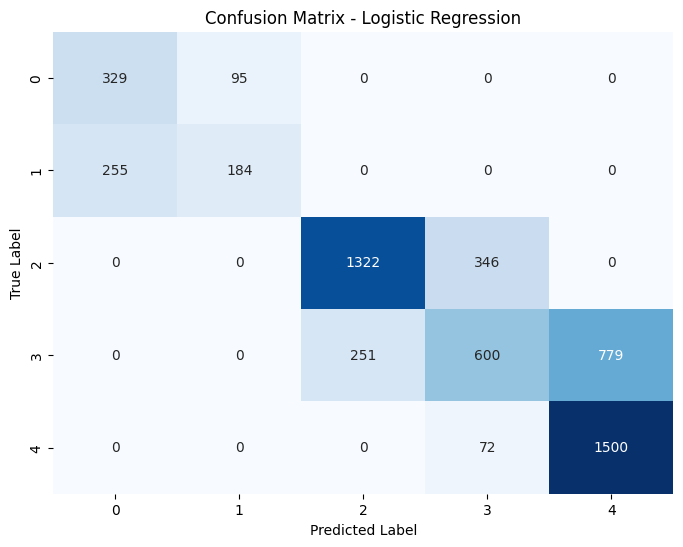

ROC Curve visualization skipped for multiclass classification.


In [78]:
# 1. Logistic Regression - Baseline model
print("\n" + "=" * 50)
print("Training Logistic Regression (Baseline model)...")
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_model, lr_cv_metrics = train_and_validate(
    lr, X_train_final, y_train_final, model_name="Logistic Regression"
)
lr_test_metrics, lr_preds = evaluate_model(
    lr_model, X_test, y_test, model_name="Logistic Regression"
)
model_results["Logistic Regression"] = {**lr_cv_metrics, **lr_test_metrics}


Training Decision Tree...

Training Decision Tree with 3-fold cross-validation...
Cross-validation results for Decision Tree:
Accuracy: 0.6968 (±0.0070)
Precision: 0.6975 (±0.0064)
Recall: 0.6968 (±0.0070)
F1 Score: 0.6971 (±0.0067)
Training time: 10.96 seconds

Decision Tree Performance:
Accuracy: 0.6156
Precision: 0.6132
Recall: 0.6156
F1 Score: 0.6143
ROC-AUC (OVR): 0.7426

Classification Report:
              precision    recall  f1-score   support

         1.0       0.54      0.58      0.56       424
         2.0       0.57      0.54      0.56       439
         3.0       0.77      0.77      0.77      1668
         4.0       0.45      0.43      0.44      1630
         5.0       0.65      0.67      0.66      1572

    accuracy                           0.62      5733
   macro avg       0.60      0.60      0.60      5733
weighted avg       0.61      0.62      0.61      5733



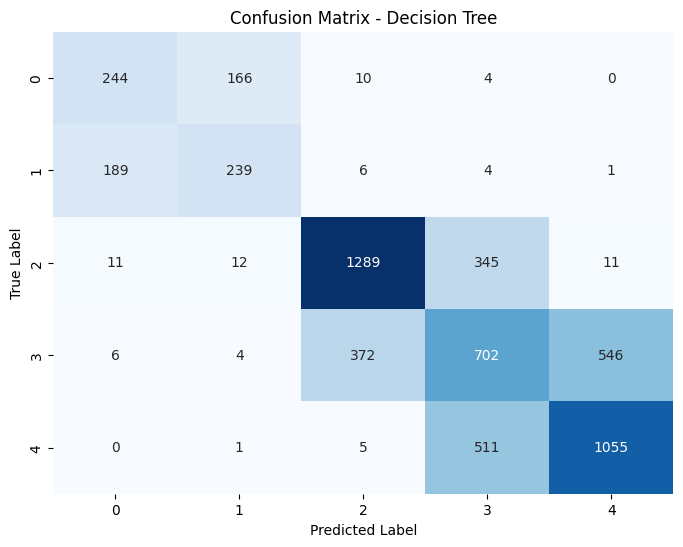

ROC Curve visualization skipped for multiclass classification.


In [79]:
# 2. Decision Tree
print("\n" + "=" * 50)
print("Training Decision Tree...")
dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_model, dt_cv_metrics = train_and_validate(
    dt, X_train_final, y_train_final, model_name="Decision Tree"
)
dt_test_metrics, dt_preds = evaluate_model(
    dt_model, X_test, y_test, model_name="Decision Tree"
)
model_results["Decision Tree"] = {**dt_cv_metrics, **dt_test_metrics}


Training Random Forest...

Training Random Forest with 3-fold cross-validation...
Cross-validation results for Random Forest:
Accuracy: 0.7819 (±0.0016)
Precision: 0.7751 (±0.0017)
Recall: 0.7819 (±0.0016)
F1 Score: 0.7614 (±0.0025)
Training time: 22.26 seconds

Random Forest Performance:
Accuracy: 0.6791
Precision: 0.6702
Recall: 0.6791
F1 Score: 0.6496
ROC-AUC (OVR): 0.8954

Classification Report:
              precision    recall  f1-score   support

         1.0       0.55      0.76      0.64       424
         2.0       0.64      0.40      0.49       439
         3.0       0.79      0.82      0.81      1668
         4.0       0.59      0.30      0.40      1630
         5.0       0.66      0.97      0.79      1572

    accuracy                           0.68      5733
   macro avg       0.65      0.65      0.63      5733
weighted avg       0.67      0.68      0.65      5733



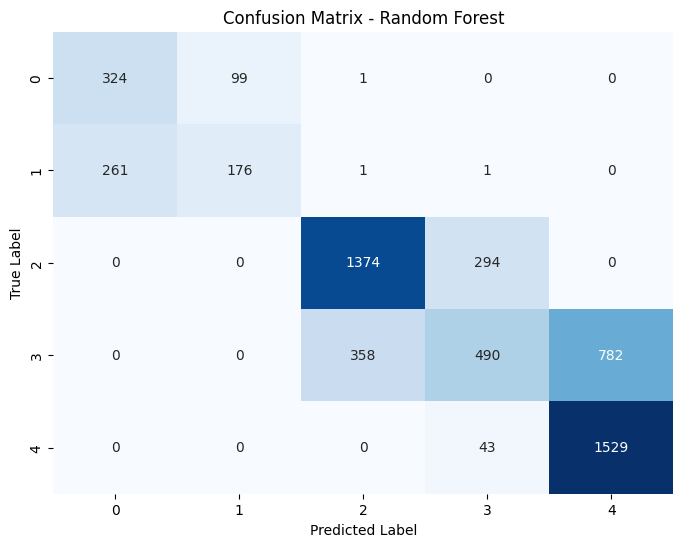

ROC Curve visualization skipped for multiclass classification.


In [80]:
# 3. Random Forest
print("\n" + "=" * 50)
print("Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=50,  # Reduced from 100
    random_state=RANDOM_STATE,
    n_jobs=-1,
    max_depth=15,  # Control tree depth
    max_features='sqrt'  # Limit features considered at each split
)
rf_model, rf_cv_metrics = train_and_validate(
    rf, X_train_final, y_train_final, model_name="Random Forest"
)
rf_test_metrics, rf_preds = evaluate_model(
    rf_model, X_test, y_test, model_name="Random Forest"
)
model_results["Random Forest"] = {**rf_cv_metrics, **rf_test_metrics}


Training Gradient Boosting...

Training Gradient Boosting with 3-fold cross-validation...
Cross-validation results for Gradient Boosting:
Accuracy: 0.7213 (±0.0012)
Precision: 0.7188 (±0.0016)
Recall: 0.7213 (±0.0012)
F1 Score: 0.7074 (±0.0012)
Training time: 548.37 seconds

Gradient Boosting Performance:
Accuracy: 0.6862
Precision: 0.6802
Recall: 0.6862
F1 Score: 0.6665
ROC-AUC (OVR): 0.9023

Classification Report:
              precision    recall  f1-score   support

         1.0       0.56      0.70      0.62       424
         2.0       0.62      0.47      0.54       439
         3.0       0.82      0.81      0.81      1668
         4.0       0.60      0.36      0.45      1630
         5.0       0.67      0.95      0.78      1572

    accuracy                           0.69      5733
   macro avg       0.65      0.66      0.64      5733
weighted avg       0.68      0.69      0.67      5733



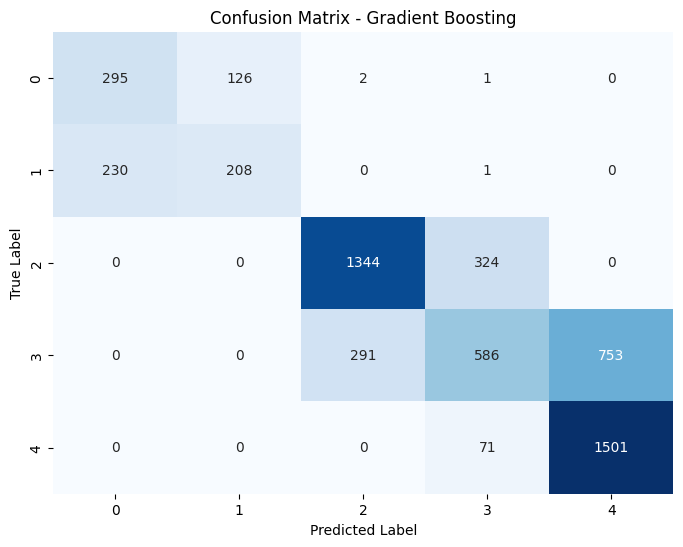

ROC Curve visualization skipped for multiclass classification.


In [39]:
# 4. Gradient Boosting Classifier
print("\n" + "=" * 50)
print("Training Gradient Boosting...")
gb = GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE)
gb_model, gb_cv_metrics = train_and_validate(
    gb, X_train_final, y_train_final, model_name="Gradient Boosting"
)
gb_test_metrics, gb_preds = evaluate_model(
    gb_model, X_test, y_test, model_name="Gradient Boosting"
)
model_results["Gradient Boosting"] = {**gb_cv_metrics, **gb_test_metrics}


Training XGBoost...

Training XGBoost with 3-fold cross-validation...
Cross-validation results for XGBoost:
Accuracy: 0.7613 (±0.0011)
Precision: 0.7582 (±0.0009)
Recall: 0.7613 (±0.0011)
F1 Score: 0.7485 (±0.0008)
Training time: 25.98 seconds

XGBoost Performance:
Accuracy: 0.6893
Precision: 0.6829
Recall: 0.6893
F1 Score: 0.6673
ROC-AUC (OVR): 0.9056

Classification Report:
              precision    recall  f1-score   support

         0.0       0.58      0.74      0.65       424
         1.0       0.65      0.48      0.56       439
         2.0       0.82      0.81      0.81      1668
         3.0       0.60      0.34      0.44      1630
         4.0       0.66      0.96      0.79      1572

    accuracy                           0.69      5733
   macro avg       0.66      0.67      0.65      5733
weighted avg       0.68      0.69      0.67      5733



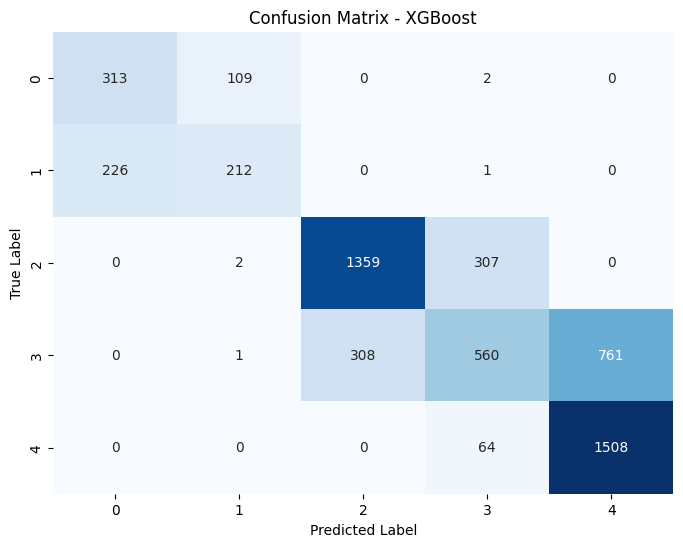

ROC Curve visualization skipped for multiclass classification.


In [81]:
# 5. XGBoost
print("\n" + "=" * 50)
print("Training XGBoost...")
xgb = XGBClassifier(
    n_estimators=100,  # Reduced from higher values if applicable
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric='logloss',
    learning_rate=0.1,  # Slightly higher learning rate
    use_label_encoder=False  # Avoid warnings
)
xgb_model, xgb_cv_metrics = train_and_validate(
    xgb, X_train_final, y_train_final-1, model_name="XGBoost"
)
xgb_test_metrics, xgb_preds = evaluate_model(
    xgb_model, X_test, y_test-1, model_name="XGBoost"
)
model_results["XGBoost"] = {**xgb_cv_metrics, **xgb_test_metrics}

In [82]:
# Compare model performance
print("\n" + "=" * 50)
print("Model Comparison:")
results_df = pd.DataFrame(model_results).T
results_df["test_accuracy"] = results_df["accuracy"]
results_df["cv_accuracy"] = results_df["accuracy"]
results_df = results_df[
    [
        "cv_accuracy",
        "test_accuracy",
        "precision",
        "recall",
        "f1",
        "auc",
        "training_time",
    ]
]
print(results_df.sort_values(by="f1", ascending=False))


Model Comparison:
                     cv_accuracy  test_accuracy  precision    recall  \
Logistic Regression     0.686377       0.686377   0.684737  0.686377   
XGBoost                 0.689342       0.689342   0.682950  0.689342   
Random Forest           0.679051       0.679051   0.670185  0.679051   
Decision Tree           0.615559       0.615559   0.613235  0.615559   

                           f1       auc  training_time  
Logistic Regression  0.667333  0.903010      15.806693  
XGBoost              0.667251  0.905562      25.981696  
Random Forest        0.649565  0.895375      22.259996  
Decision Tree        0.614260  0.742636      10.959659  


In [83]:
# Identify the best model based on F1-score
best_model_name = results_df["f1"].idxmax()
print(
    f"\nBest performing model: {best_model_name} with F1 score of {results_df.loc[best_model_name, 'f1']:.4f}"
)


Best performing model: Logistic Regression with F1 score of 0.6673


In [84]:
# Select the best base model for hyperparameter tuning
if best_model_name == "Logistic Regression":
    best_base_model = LogisticRegression(random_state=RANDOM_STATE)
    param_grid = {
        "C": [0.001, 0.01, 0.1, 1, 10, 100],
        "penalty": ["l1", "l2", "elasticnet", None],
        "solver": ["newton-cg", "lbfgs", "liblinear", "sag", "saga"],
    }
elif best_model_name == "Decision Tree":
    best_base_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
    param_grid = {
        "max_depth": [None, 5, 10, 15, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "criterion": ["gini", "entropy"],
    }
elif best_model_name == "Random Forest":
    best_base_model = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
    param_grid = {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2", None],
    }
elif best_model_name == "Gradient Boosting":
    best_base_model = GradientBoostingClassifier(random_state=RANDOM_STATE)
    param_grid = {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.1, 0.2],
        "max_depth": [3, 5, 7],
        "min_samples_split": [2, 5],
        "subsample": [0.8, 1.0],
    }
else:  # XGBoost
    best_base_model = XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1)
    param_grid = {
        # Example for XGBoost - simplified grid
        "n_estimators": [50, 100],  # Fewer options
        "learning_rate": [0.1, 0.3],  # Fewer options
        "max_depth": [3, 5],
        "subsample": [0.8],
        "colsample_bytree": [0.8]
    }

---

## Hyperparameter Tuning

In [85]:
print("\n" + "=" * 50)
print(f"Performing hyperparameter tuning for {best_model_name}...")

# Use RandomizedSearchCV for efficiency
random_search = RandomizedSearchCV(
    estimator=best_base_model,
    param_distributions=param_grid,
    n_iter=10,  # Reduced from 20
    cv=3,  # Reduced from 5
    scoring="f1_weighted",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

# Fit RandomizedSearchCV
start_time = time()
random_search.fit(X_train_final, y_train_final)
end_time = time()


Performing hyperparameter tuning for Logistic Regression...
Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [86]:
print(f"Hyperparameter tuning completed in {end_time - start_time:.2f} seconds")
print(f"Best parameters: {random_search.best_params_}")
print(f"Best cross-validated F1 score: {random_search.best_score_:.4f}")

Hyperparameter tuning completed in 218.32 seconds
Best parameters: {'solver': 'saga', 'penalty': 'l1', 'C': 0.1}
Best cross-validated F1 score: 0.7027


In [87]:
# Get the best model
best_model = random_search.best_estimator_


Evaluating tuned model on test set...

Tuned Logistic Regression Performance:
Accuracy: 0.6991
Precision: 0.7015
Recall: 0.6991
F1 Score: 0.6786
ROC-AUC (OVR): 0.9058

Classification Report:
              precision    recall  f1-score   support

         1.0       0.57      0.82      0.67       424
         2.0       0.69      0.40      0.50       439
         3.0       0.85      0.82      0.84      1668
         4.0       0.63      0.37      0.47      1630
         5.0       0.66      0.96      0.78      1572

    accuracy                           0.70      5733
   macro avg       0.68      0.67      0.65      5733
weighted avg       0.70      0.70      0.68      5733



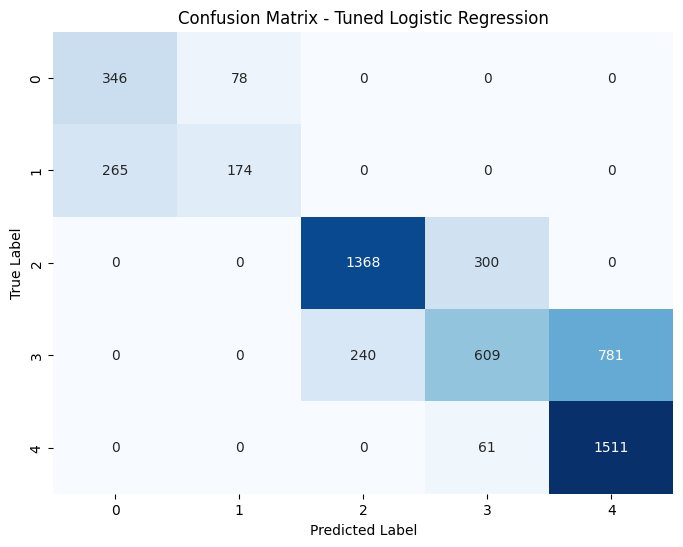

ROC Curve visualization skipped for multiclass classification.


In [88]:
# Evaluate the tuned model
print("\nEvaluating tuned model on test set...")
tuned_metrics, tuned_preds = evaluate_model(
    best_model, X_test, y_test, model_name=f"Tuned {best_model_name}"
)

In [89]:
# Compare with base model
print("\nComparison between base and tuned models:")
comparison_df = pd.DataFrame(
    {
        f"Base {best_model_name}": results_df.loc[best_model_name],
        f"Tuned {best_model_name}": {
            "cv_accuracy": random_search.best_score_,  # This is actually F1 score as we used 'f1_weighted' for scoring
            "test_accuracy": tuned_metrics["accuracy"],
            "precision": tuned_metrics["precision"],
            "recall": tuned_metrics["recall"],
            "f1": tuned_metrics["f1"],
            "auc": tuned_metrics.get("auc", np.nan),
            "training_time": end_time - start_time,
        },
    }
)
print(comparison_df.T)


Comparison between base and tuned models:
                           cv_accuracy  test_accuracy  precision    recall  \
Base Logistic Regression      0.686377       0.686377   0.684737  0.686377   
Tuned Logistic Regression     0.702694       0.699110   0.701549  0.699110   

                                 f1      auc  training_time  
Base Logistic Regression   0.667333  0.90301      15.806693  
Tuned Logistic Regression  0.678644  0.90576     218.320704  



Feature Importance Analysis:

Top 20 Features by Coefficient Magnitude:
     Feature  Coefficient
53        53     3.728222
3          3     1.938113
21        21    -1.290892
31        31     1.193672
34        34    -0.838198
45        45    -0.668284
33        33    -0.580043
26        26     0.534582
91        91    -0.448778
58        58     0.387308
4          4     0.356959
39        39     0.339064
35        35    -0.321894
14        14     0.321407
96        96     0.294893
28        28     0.249515
78        78    -0.233570
7          7    -0.232352
105      105    -0.218390
76        76     0.213227


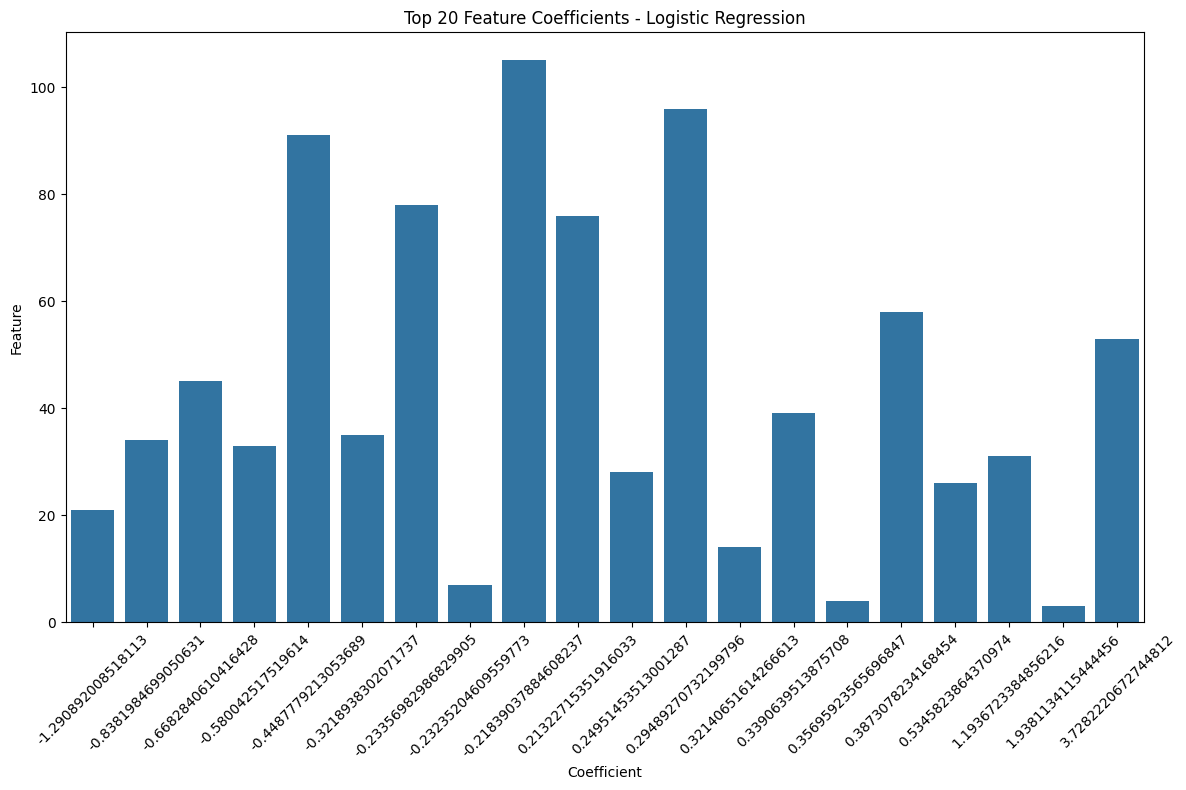

In [97]:
# Feature importance analysis (if applicable)
print("\n" + "=" * 50)
print("Feature Importance Analysis:")

if hasattr(best_model, "feature_importances_"):
    # Get feature importances
    feature_importances = best_model.feature_importances_

    # Create a DataFrame for easier visualization
    feature_importance_df = pd.DataFrame(
        {
            "Feature": range(
                X_train_final.shape[1]
            ),  # We don't have feature names available
            "Importance": feature_importances,
        }
    )

    # Sort by importance
    feature_importance_df = feature_importance_df.sort_values(
        "Importance", ascending=False
    )

    # Display top 20 features
    print("\nTop 20 Features by Importance:")
    print(feature_importance_df.head(20))

    # Plot feature importances
    plt.figure(figsize=(12, 8))
    sns.barplot(x="Importance", y="Feature", data=feature_importance_df.head(20))
    plt.title(f"Top 20 Feature Importances - {best_model_name}")
    plt.tight_layout()
    plt.show()
elif hasattr(best_model, "coef_"):
    # For linear models
    coefficients = (
        best_model.coef_[0] if best_model.coef_.ndim > 1 else best_model.coef_
    )

    # Create a DataFrame for easier visualization
    feature_importance_df = pd.DataFrame(
        {
            "Feature": range(
                len(coefficients)
            ),  # We don't have feature names available
            "Coefficient": coefficients,
        }
    )

    # Sort by absolute value
    feature_importance_df["AbsCoef"] = feature_importance_df["Coefficient"].abs()
    feature_importance_df = feature_importance_df.sort_values(
        "AbsCoef", ascending=False
    )

    # Display top 20 features
    print("\nTop 20 Features by Coefficient Magnitude:")
    print(feature_importance_df[["Feature", "Coefficient"]].head(20))

    # Plot coefficients
    plt.figure(figsize=(12, 8))
    sns.barplot(x="Coefficient", y="Feature", data=feature_importance_df.head(20))
    plt.title(f"Top 20 Feature Coefficients - {best_model_name}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Feature importance not available for this model type.")

---

## Model Saving

In [91]:
print("\n" + "=" * 50)
print("Saving the best model...")

# Save the final model
final_model = best_model
model_filename = f'best_churn_model_{best_model_name.replace(" ", "_").lower()}.pkl'

with open(model_filename, "wb") as file:
    pickle.dump(final_model, file)

print(f"Model saved as {model_filename}")


Saving the best model...
Model saved as best_churn_model_logistic_regression.pkl


In [ ]:
# Save the complete pipeline including preprocessing and model
final_pipeline = Pipeline([("preprocessing", complete_pipeline), ("model", final_model)])

pipeline_filename = "complete_churn_pipeline.pkl"
with open(pipeline_filename, "wb") as file:
    pickle.dump(final_pipeline, file)

print(f"Complete pipeline saved as {pipeline_filename}")

Complete pipeline saved as complete_churn_pipeline.pkl


---

## Generating Report

In [98]:
print("\n" + "=" * 50)
print("Generating Final Model Evaluation Report...")

# Create a comprehensive model report
report = {
    "Model Name": best_model_name,
    "Tuned Parameters": random_search.best_params_,
    "Performance Metrics": {
        "Accuracy": tuned_metrics["accuracy"],
        "Precision": tuned_metrics["precision"],
        "Recall": tuned_metrics["recall"],
        "F1 Score": tuned_metrics["f1"],
        "AUC-ROC": tuned_metrics.get("auc", "N/A"),
    },
    "Cross-Validation": {
        "Method": "5-fold stratified cross-validation",
        "Best CV Score": random_search.best_score_,
    },
    "Training Information": {
        "Training Set Size": X_train_final.shape,
        "Test Set Size": X_test.shape,
        "Class Distribution": pd.Series(y_train_final)
        .value_counts(normalize=True)
        .to_dict(),
        "Class Balancing": (
            "SMOTE" if min_class_percentage < imbalance_threshold else "None"
        ),
    },
}
# Print report summary
print("\nFinal Model Report Summary:")
print(f"Model: {report['Model Name']}")
print("\nPerformance Metrics:")
for metric, value in report["Performance Metrics"].items():
    print(
        f"  {metric}: {value:.4f}"
        if isinstance(value, float)
        else f"  {metric}: {value}"
    )

print("\nCross-Validation:")
print(f"  Method: {report['Cross-Validation']['Method']}")
print(f"  Best CV Score: {report['Cross-Validation']['Best CV Score']:.4f}")

print("\nTraining Information:")
print(f"  Training Set Size: {report['Training Information']['Training Set Size']}")
print(f"  Test Set Size: {report['Training Information']['Test Set Size']}")
print(f"  Class Balancing: {report['Training Information']['Class Balancing']}")


Generating Final Model Evaluation Report...

Final Model Report Summary:
Model: Logistic Regression

Performance Metrics:
  Accuracy: 0.6991
  Precision: 0.7015
  Recall: 0.6991
  F1 Score: 0.6786
  AUC-ROC: 0.9058

Cross-Validation:
  Method: 5-fold stratified cross-validation
  Best CV Score: 0.7027

Training Information:
  Training Set Size: (33355, 110)
  Test Set Size: (5733, 110)
  Class Balancing: SMOTE


In [95]:
# Save the report
report_filename = "model_evaluation_report.pkl"
with open(report_filename, "wb") as file:
    pickle.dump(report, file)

print(f"\nModel evaluation report saved as {report_filename}")


Model evaluation report saved as model_evaluation_report.pkl


---

## Predicition Function

In [99]:
print("\n" + "=" * 50)
def predict_churn(new_data, pipeline=final_pipeline):
    """
    Predict churn risk for new customer data

    Parameters:
    -----------
    new_data : pandas DataFrame
        New customer data to predict churn risk for
    pipeline : sklearn Pipeline
        Complete pipeline including preprocessing and model

    Returns:
    --------
    predictions : numpy array
        Predicted churn risk (0 or 1)
    probabilities : numpy array
        Probability of churn risk (if model supports predict_proba)
    """
    # Make predictions
    predictions = pipeline.predict(new_data)

    # Get probabilities if available
    try:
        probabilities = pipeline.predict_proba(new_data)[:, 1]
    except:
        probabilities = None

    return predictions, probabilities